# OpenVINO Object Detection: CPU vs GPU Benchmark

This notebook downloads a pretrained object detection model, exports it straight to
OpenVINO IR, and runs inference on both **CPU** and **GPU** (if available), comparing
inference latency and detection results side by side.

> **Note on this update:** the original version used Open Model Zoo's `omz_downloader` /
> `omz_converter`, which shipped with the `openvino-dev` package. `openvino-dev` (and the
> legacy Model Optimizer / OMZ tooling) has been discontinued, so this notebook now fetches
> a small YOLO model via [Ultralytics](https://docs.ultralytics.com/) and exports it directly
> to OpenVINO IR using `model.export(format="openvino")` — no `openvino-dev` or Model
> Optimizer required, just the `openvino` and `ultralytics` packages.

Sections:
1. Setup & imports
2. Model download & OpenVINO IR export (Ultralytics YOLO)
3. Pre/post-processing helpers
4. Load an input image
5. Compile & run on CPU
6. Compile & run on GPU (falls back gracefully if no GPU is present)
7. Compare latency + visualize detections side by side


## 1. Setup & imports

In [4]:
import shutil
import time
from pathlib import Path
from typing import Any

import numpy as np

try:
    import openvino as ov
except ImportError as exc:
    raise SystemExit(
        "OpenVINO is not installed in this environment. Run: pip install -U openvino"
    ) from exc

print("OpenVINO version:", ov.__version__)


OpenVINO version: 2026.2.1-21919-ede283a88e3-releases/2026/2


In [5]:
# Check which devices OpenVINO can see on this machine (e.g. ['CPU'] or ['CPU', 'GPU'])
core = ov.Core()
available_devices = core.available_devices
print("Available devices:", available_devices)
for d in available_devices:
    try:
        full_name = core.get_property(d, "FULL_DEVICE_NAME")
        print(f"  {d}: {full_name}")
    except Exception as e:
        print(f"  {d}: (could not query name: {e})")


Available devices: ['CPU', 'GPU']
  CPU: 13th Gen Intel(R) Core(TM) i7-1365U
  GPU: Intel(R) Iris(R) Xe Graphics (iGPU)


## 2. Model download & OpenVINO IR export

Uses [Ultralytics](https://docs.ultralytics.com/) to download a pretrained YOLO
checkpoint and export it directly to OpenVINO IR — this replaces the old
`omz_downloader` / `omz_converter` (`openvino-dev`) workflow, which no longer ships.

Requires the `ultralytics` package: `pip install -U ultralytics`.
Edit `MODEL_NAME` / `IR_PRECISION` below if needed (e.g. `"yolov8n"`, `"yolo11s"`).


In [ ]:
MODEL_NAME = "yolo11n"  # Ultralytics model id, e.g. "yolov8n", "yolo11n", "yolo11s"
MODELS_ROOT = Path("models")
IR_PRECISION = "FP16"  # "FP16" or "FP32"

# Standard 80-class COCO label order used by Ultralytics YOLO models.
COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck",
    "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra",
    "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
    "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush",
]


def ensure_yolo_openvino_model(model_name: str, output_root: Path, precision: str = "FP16"):
    try:
        from ultralytics import YOLO
    except ImportError as exc:
        raise SystemExit(
            "The 'ultralytics' package is required to fetch and convert the model.\n"
            "Install it with: pip install -U ultralytics"
        ) from exc

    output_root.mkdir(parents=True, exist_ok=True)
    target_dir = output_root / f"{model_name}_openvino_model"

    existing = list(target_dir.glob("*.xml")) if target_dir.exists() else []
    if existing:
        print(f"Using existing converted model: {existing[0]}")
        return existing[0]

    print(f"Downloading '{model_name}' and exporting to OpenVINO IR ...")
    model = YOLO(f"{model_name}.pt")
    export_result = model.export(format="openvino", half=(precision == "FP16"))
    exported_path = Path(export_result)
    exported_dir = exported_path if exported_path.is_dir() else exported_path.parent

    if exported_dir.resolve() != target_dir.resolve():
        target_dir.parent.mkdir(parents=True, exist_ok=True)
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.move(str(exported_dir), str(target_dir))

    converted = list(target_dir.glob("*.xml"))
    if not converted:
        raise SystemExit(f"Expected an exported .xml under {target_dir}, but none was found.")
    return converted[0]


In [6]:
model_xml = ensure_yolo_openvino_model(MODEL_NAME, MODELS_ROOT, IR_PRECISION)
print("Model IR:", model_xml)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/ubuntu/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (13th Gen Intel Core i7-1365U)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)

OpenVINO: starting export with openvino 2026.2.1-21919-ede283a88e3-releases/2026/2...
OpenVINO: export success ✅ 3.2s, saved as 'yolo11n_openvino_model/' (

## 3. Pre/post-processing helpers

Image loading/resizing, YOLO output decoding (box decode + per-class NMS), and drawing.


In [7]:
def load_rgb_with_pillow(image_path: Path) -> np.ndarray:
    from PIL import Image
    image = Image.open(image_path).convert("RGB")
    return np.array(image, dtype=np.uint8)


def resize_rgb_nearest(image: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
    src_h, src_w = image.shape[:2]
    if src_h == target_h and src_w == target_w:
        return image
    y_idx = np.linspace(0, src_h - 1, target_h).astype(np.int32)
    x_idx = np.linspace(0, src_w - 1, target_w).astype(np.int32)
    return image[y_idx][:, x_idx]


def preprocess(input_shape, source_image=None, input_dtype=np.float32):
    if len(input_shape) != 4:
        raise SystemExit(f"Unexpected input shape: {input_shape}")
    n, d1, d2, d3 = input_shape
    if n != 1:
        raise SystemExit(f"Only batch size 1 is supported: {input_shape}")

    if d3 == 3:
        if source_image is None:
            frame = np.random.randint(0, 255, size=(d1, d2, 3), dtype=np.uint8)
        else:
            frame = resize_rgb_nearest(source_image, d1, d2)
        data = frame[np.newaxis, ...]
    elif d1 == 3:
        if source_image is None:
            frame = np.random.randint(0, 255, size=(d2, d3, 3), dtype=np.uint8)
        else:
            frame = resize_rgb_nearest(source_image, d2, d3)
        data = np.transpose(frame, (2, 0, 1))[np.newaxis, ...]
    else:
        raise SystemExit(f"Unsupported input layout: {input_shape}")

    data = data.astype(np.float32)
    if input_dtype != np.uint8:
        # YOLO models expect pixels scaled to [0, 1]
        data = data / 255.0

    return data.astype(input_dtype), frame


def _nms_xyxy(boxes: np.ndarray, scores: np.ndarray, iou_threshold: float = 0.45):
    if len(boxes) == 0:
        return []
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = np.maximum(0.0, x2 - x1) * np.maximum(0.0, y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        order = order[1:][iou <= iou_threshold]
    return keep


def parse_yolo_output(outputs, threshold, input_hw, iou_threshold=0.45):
    """Decode an Ultralytics-exported YOLO OpenVINO output tensor.

    Expected raw shape: (1, 4 + num_classes, num_boxes) -- box coords are in
    input-pixel space (cx, cy, w, h), followed by per-class scores (no separate
    objectness term). Returns (label, score, xmin, ymin, xmax, ymax) with
    normalized [0, 1] coordinates, same format the original SSD parser used.
    """
    raw = np.squeeze(np.asarray(next(iter(outputs.values()))))

    # Normalize to (num_boxes, 4 + num_classes)
    preds = raw.T if raw.shape[0] < raw.shape[1] else raw

    box_xywh = preds[:, :4]
    class_scores = preds[:, 4:]
    class_ids = np.argmax(class_scores, axis=1)
    scores = class_scores[np.arange(len(class_ids)), class_ids]

    keep_mask = scores >= threshold
    box_xywh = box_xywh[keep_mask]
    class_ids = class_ids[keep_mask]
    scores = scores[keep_mask]
    if len(scores) == 0:
        return []

    in_h, in_w = input_hw
    cx, cy, w, h = box_xywh[:, 0], box_xywh[:, 1], box_xywh[:, 2], box_xywh[:, 3]
    boxes_xyxy = np.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], axis=1)

    detections = []
    for class_id in np.unique(class_ids):
        cls_mask = class_ids == class_id
        cls_boxes = boxes_xyxy[cls_mask]
        cls_scores = scores[cls_mask]
        for idx in _nms_xyxy(cls_boxes, cls_scores, iou_threshold):
            xmin, ymin, xmax, ymax = cls_boxes[idx]
            detections.append((
                int(class_id),
                float(cls_scores[idx]),
                float(np.clip(xmin / in_w, 0, 1)),
                float(np.clip(ymin / in_h, 0, 1)),
                float(np.clip(xmax / in_w, 0, 1)),
                float(np.clip(ymax / in_h, 0, 1)),
            ))
    return detections


def draw_detections_with_pillow(rgb_image, detections, class_names=None):
    from PIL import Image, ImageDraw
    image = Image.fromarray(rgb_image)
    draw = ImageDraw.Draw(image)
    width, height = image.size
    for label, score, xmin, ymin, xmax, ymax in detections:
        x1 = int(max(0, xmin) * width)
        y1 = int(max(0, ymin) * height)
        x2 = int(min(1, xmax) * width)
        y2 = int(min(1, ymax) * height)
        name = class_names[label] if class_names and label < len(class_names) else str(label)
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        draw.text((x1 + 2, max(0, y1 - 12)), f"{name} {score:.2f}", fill="red")
    return image


## 4. Load an input image

Set `IMAGE_PATH` to a real image for meaningful detections. If left as `None`, a random
synthetic image is used (fine for timing comparisons, but won't produce real detections).


In [8]:
IMAGE_PATH = "images/sample.jpg"  # e.g. Path("sample.jpg")
THRESHOLD = 0.5

source_image = None
if IMAGE_PATH is not None:
    source_image = load_rgb_with_pillow(Path(IMAGE_PATH))
    print("Loaded image:", IMAGE_PATH, source_image.shape)
else:
    print("No IMAGE_PATH set -- using synthetic random input for benchmarking only.")


Loaded image: images/sample.jpg (1000, 1500, 3)


## 5 & 6. Compile & benchmark on each device

This helper compiles the model on a given device, runs a warm-up inference, then times
`N_RUNS` inferences to get an average latency. It also returns the parsed detections and
the annotated frame for visual comparison.


In [9]:
N_RUNS = 20  # number of timed inference iterations per device


def benchmark_device(model_xml: Path, device: str, source_image, threshold: float, n_runs: int = N_RUNS):
    model = core.read_model(model=str(model_xml))
    compiled = core.compile_model(model, device)

    input_port = compiled.input(0)
    input_shape = list(input_port.shape)
    input_type_name = str(input_port.element_type).lower()
    input_dtype = np.uint8 if "u8" in input_type_name else np.float32

    input_tensor, prepared_image = preprocess(input_shape, source_image, input_dtype=input_dtype)

    # Warm-up run (excluded from timing -- first inference includes extra setup cost)
    _ = compiled([input_tensor])

    latencies = []
    for _ in range(n_runs):
        start = time.perf_counter()
        outputs = compiled([input_tensor])
        latencies.append(time.perf_counter() - start)

    detections = parse_yolo_output(outputs, threshold, prepared_image.shape[:2])

    return {
        "device": device,
        "latencies_ms": [l * 1000 for l in latencies],
        "mean_ms": float(np.mean(latencies) * 1000),
        "std_ms": float(np.std(latencies) * 1000),
        "fps": 1.0 / float(np.mean(latencies)),
        "detections": detections,
        "prepared_image": prepared_image,
    }


In [10]:
results = {}

# --- CPU ---
print("Running on CPU...")
results["CPU"] = benchmark_device(model_xml, "CPU", source_image, THRESHOLD)
print(f"CPU: {results['CPU']['mean_ms']:.2f} ms/frame  ({results['CPU']['fps']:.1f} FPS)  "
      f"detections={len(results['CPU']['detections'])}")


Running on CPU...
CPU: 132.73 ms/frame  (7.5 FPS)  detections=1


In [11]:
# --- GPU (falls back gracefully if no GPU device is present) ---
if "GPU" in available_devices:
    print("Running on GPU...")
    try:
        results["GPU"] = benchmark_device(model_xml, "GPU", source_image, THRESHOLD)
        print(f"GPU: {results['GPU']['mean_ms']:.2f} ms/frame  ({results['GPU']['fps']:.1f} FPS)  "
              f"detections={len(results['GPU']['detections'])}")
    except Exception as e:
        print(f"GPU run failed: {e}")
else:
    print("No GPU device detected by OpenVINO (available_devices =", available_devices, ")")
    print("On Linux this usually means the Intel GPU driver / compute runtime "
          "(intel-opencl-icd / intel-media-va-driver) isn't installed, or you're on non-Intel GPU hardware "
          "that OpenVINO's GPU plugin doesn't target.")


Running on GPU...
GPU: 11.14 ms/frame  (89.8 FPS)  detections=1


## 7. Compare results

In [12]:
print(f"{'Device':<8} {'Mean (ms)':>10} {'Std (ms)':>10} {'FPS':>8} {'Detections':>11}")
for dev, r in results.items():
    print(f"{dev:<8} {r['mean_ms']:>10.2f} {r['std_ms']:>10.2f} {r['fps']:>8.1f} {len(r['detections']):>11}")

if "CPU" in results and "GPU" in results:
    speedup = results["CPU"]["mean_ms"] / results["GPU"]["mean_ms"]
    faster = "GPU" if speedup > 1 else "CPU"
    print(f"\n{faster} is {max(speedup, 1/speedup):.2f}x faster on this model/hardware.")


Device    Mean (ms)   Std (ms)      FPS  Detections
CPU          132.73      12.05      7.5           1
GPU           11.14       0.70     89.8           1

GPU is 11.92x faster on this model/hardware.


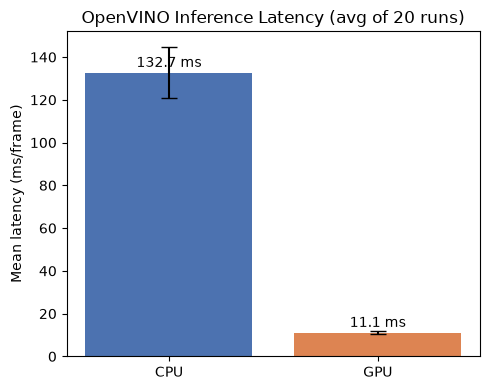

In [13]:
import matplotlib.pyplot as plt

devices = list(results.keys())
means = [results[d]["mean_ms"] for d in devices]
stds = [results[d]["std_ms"] for d in devices]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(devices, means, yerr=stds, capsize=6, color=["#4C72B0", "#DD8452"][: len(devices)])
ax.set_ylabel("Mean latency (ms/frame)")
ax.set_title(f"OpenVINO Inference Latency (avg of {N_RUNS} runs)")
for i, v in enumerate(means):
    ax.text(i, v + max(means) * 0.02, f"{v:.1f} ms", ha="center")
plt.tight_layout()
plt.show()


### Side-by-side annotated frames

Only meaningful if a real `IMAGE_PATH` was set above (random synthetic input rarely
produces confident detections).


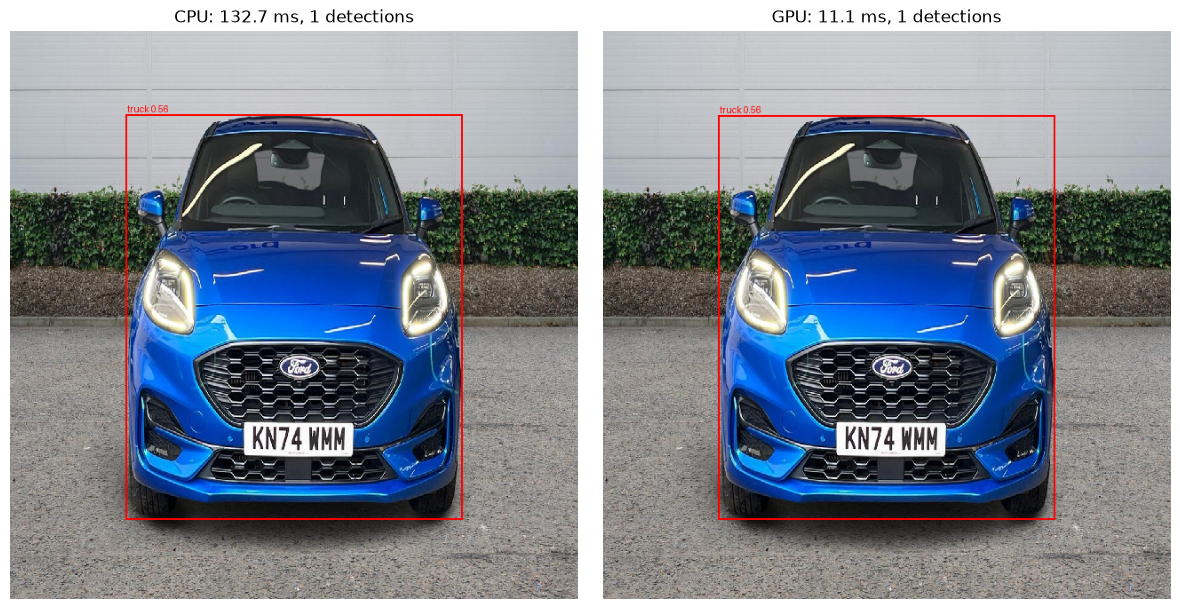

In [14]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
if len(results) == 1:
    axes = [axes]

for ax, (dev, r) in zip(axes, results.items()):
    annotated = draw_detections_with_pillow(r["prepared_image"], r["detections"], class_names=COCO_CLASSES)
    ax.imshow(annotated)
    ax.set_title(f"{dev}: {r['mean_ms']:.1f} ms, {len(r['detections'])} detections")
    ax.axis("off")

plt.tight_layout()
plt.show()
